In [1]:
# Importando o NumPy para trabalhar com operações numéricas
import numpy as np

# Importando o Pandas para carregar e manipular os dados
import pandas as pd

# Importando o Matplotlib para criar os gráficos
import matplotlib.pyplot as plt

# Importando o módulo os para acessar os arquivos do Kaggle
import os

# Importando o módulo responsável pela divisão dos dados
# e também pela validação cruzada
import sklearn.model_selection

# Importando o módulo utilizado para padronizar os dados
import sklearn.preprocessing

# Importando o módulo Pipeline
import sklearn.pipeline

# Importando o módulo que contém o Support Vector Machine
import sklearn.svm

# Importando o módulo que contém as métricas de avaliação
import sklearn.metrics

# Definindo um tamanho padrão para os gráficos
plt.rcParams["figure.figsize"] = (8, 5)

# Classificação do Dataset Iris utilizando SVM

## 1. Introdução

Neste trabalho, vamos analisar o dataset Iris, que contém informações sobre diferentes espécies de flores. O objetivo é entender melhor os dados e, depois, utilizar o algoritmo Support Vector Machine (SVM) para identificar a espécie de uma flor a partir de suas características.

Os dados utilizados foram obtidos diretamente do Kaggle e estão vinculados a este notebook, conforme solicitado na atividade.

Durante a análise, vamos conhecer melhor o dataset, verificar como os dados estão distribuídos, preparar as informações para o treinamento e, por fim, avaliar o desempenho do modelo SVM.

## 2. Carregamento dos dados

Antes de começar a análise, precisamos localizar o arquivo do dataset que foi disponibilizado pelo Kaggle.

Como o dataset Iris já está vinculado a este notebook, seus arquivos ficam disponíveis dentro da pasta `/kaggle/input`. Nesta etapa, vamos verificar quais arquivos foram adicionados e identificar o caminho correto do arquivo que será utilizado durante o trabalho.

Dessa forma, garantimos que os dados utilizados realmente são os que foram fornecidos pelo dataset do Kaggle.

In [2]:
# Guardando o caminho do arquivo Iris.csv que está anexado ao notebook
caminho_arquivo = '/kaggle/input/datasets/menegidio/iris-species/Iris.csv'

# Lendo o arquivo CSV com o Pandas
# Os dados serão armazenados na variável df para utilizarmos durante a análise
df = pd.read_csv(caminho_arquivo)

# Mostrando as 5 primeiras linhas para conferir se o arquivo foi carregado corretamente
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 3. Conhecendo o dataset

Agora que os dados foram carregados, o próximo passo é entender melhor como o dataset está organizado.

Antes de começar a criar gráficos ou treinar o modelo, é importante verificar a quantidade de linhas e colunas, os nomes das variáveis e os tipos de dados presentes. Também vamos verificar se existem valores ausentes, pois esse tipo de problema pode interferir no treinamento do modelo.

Essa análise inicial ajuda a conhecer melhor os dados com os quais vamos trabalhar e identificar se será necessário realizar algum tratamento antes de utilizar o SVM.

In [3]:
# Mostrando a quantidade de linhas e colunas presentes no dataset
print("Quantidade de linhas e colunas:", df.shape)

# Mostrando os nomes das colunas disponíveis no dataset
print("\nColunas do dataset:")

# Percorrendo as colunas para mostrar cada uma de forma organizada
for coluna in df.columns:
    print("-", coluna)

Quantidade de linhas e colunas: (150, 6)

Colunas do dataset:
- Id
- SepalLengthCm
- SepalWidthCm
- PetalLengthCm
- PetalWidthCm
- Species


### Verificando os tipos dos dados

Depois de conhecer o tamanho e as colunas do dataset, vamos verificar o tipo de dado presente em cada variável.

Essa etapa é importante para entender quais colunas possuem valores numéricos e quais possuem informações em formato de texto. Também conseguimos verificar se todas as linhas estão preenchidas corretamente antes de continuar a análise.

In [4]:
# Mostrando informações gerais sobre o dataset
# O info() apresenta as colunas, quantidade de valores preenchidos
# e o tipo de dado armazenado em cada uma delas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


### Verificação de valores ausentes

Também precisamos verificar se existem valores ausentes no dataset.

Dados faltantes podem causar problemas durante a análise e o treinamento do modelo. Por isso, vamos contar quantos valores ausentes existem em cada coluna antes de continuar.

In [5]:
# Contando a quantidade de valores ausentes em cada coluna
valores_ausentes = df.isnull().sum()

# Mostrando a quantidade encontrada em cada coluna
print("Valores ausentes por coluna:")
print(valores_ausentes)

# Somando todos os valores ausentes para verificar o total do dataset
print("\nTotal de valores ausentes:", valores_ausentes.sum())

Valores ausentes por coluna:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Total de valores ausentes: 0


### Estatísticas descritivas

Agora vamos observar algumas informações estatísticas das variáveis numéricas do dataset.

Com essa análise, podemos visualizar valores como média, desvio padrão, mínimo, máximo e quartis. Isso ajuda a entender melhor como as medidas das sépalas e pétalas estão distribuídas antes de partir para as análises gráficas.

In [6]:
# Gerando um resumo estatístico das colunas numéricas do dataset
estatisticas = df.describe()

# Exibindo as estatísticas encontradas
estatisticas

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


## 4. Análise Exploratória dos Dados (EDA)

Depois de conhecer a estrutura do dataset e verificar que não existem valores ausentes, podemos analisar melhor o comportamento dos dados.

Nesta etapa, vamos observar como as espécies estão distribuídas e analisar as características das flores através de gráficos. Isso ajuda a identificar diferenças e padrões entre as espécies antes de utilizar o modelo SVM.

Primeiro, vamos verificar quantas amostras existem de cada espécie no dataset.

In [7]:
# Contando quantas flores existem de cada espécie no dataset
quantidade_especies = df["Species"].value_counts()

# Mostrando a quantidade encontrada para cada espécie
print("Quantidade de flores por espécie:")
print(quantidade_especies)

Quantidade de flores por espécie:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


### Distribuição das espécies

A contagem das espécies mostrou que o dataset possui 50 amostras de cada uma das três espécies: Iris-setosa, Iris-versicolor e Iris-virginica.

Isso mostra que as classes estão balanceadas, ou seja, nenhuma espécie possui uma quantidade maior de exemplos do que as outras. Essa distribuição é positiva para o treinamento do modelo, pois evita que uma classe tenha uma influência muito maior durante o aprendizado.

Para visualizar melhor essa distribuição, vamos representar essas quantidades através de um gráfico de barras.

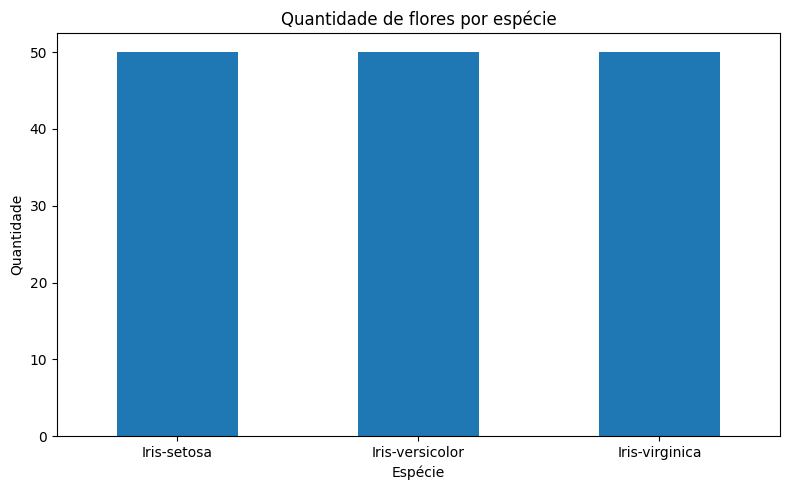

In [8]:
# Criando um gráfico de barras com a quantidade de flores de cada espécie
quantidade_especies.plot(kind="bar")

# Adicionando um título para facilitar a interpretação do gráfico
plt.title("Quantidade de flores por espécie")

# Definindo o nome do eixo horizontal
plt.xlabel("Espécie")

# Definindo o nome do eixo vertical
plt.ylabel("Quantidade")

# Ajustando os nomes das espécies para ficarem na horizontal
plt.xticks(rotation=0)

# Ajustando automaticamente o espaço dos elementos do gráfico
plt.tight_layout()

# Exibindo o gráfico
plt.show()

### Distribuição das características das flores

Depois de analisar a quantidade de amostras de cada espécie, vamos observar como estão distribuídas as medidas das flores.

O dataset possui quatro características principais: comprimento e largura da sépala, além do comprimento e largura da pétala. Essas são as informações que serão utilizadas posteriormente pelo modelo SVM para realizar a classificação das espécies.

Para entender melhor o comportamento dessas medidas, vamos utilizar histogramas. Eles permitem visualizar quais valores aparecem com maior frequência e como cada característica está distribuída no conjunto de dados.

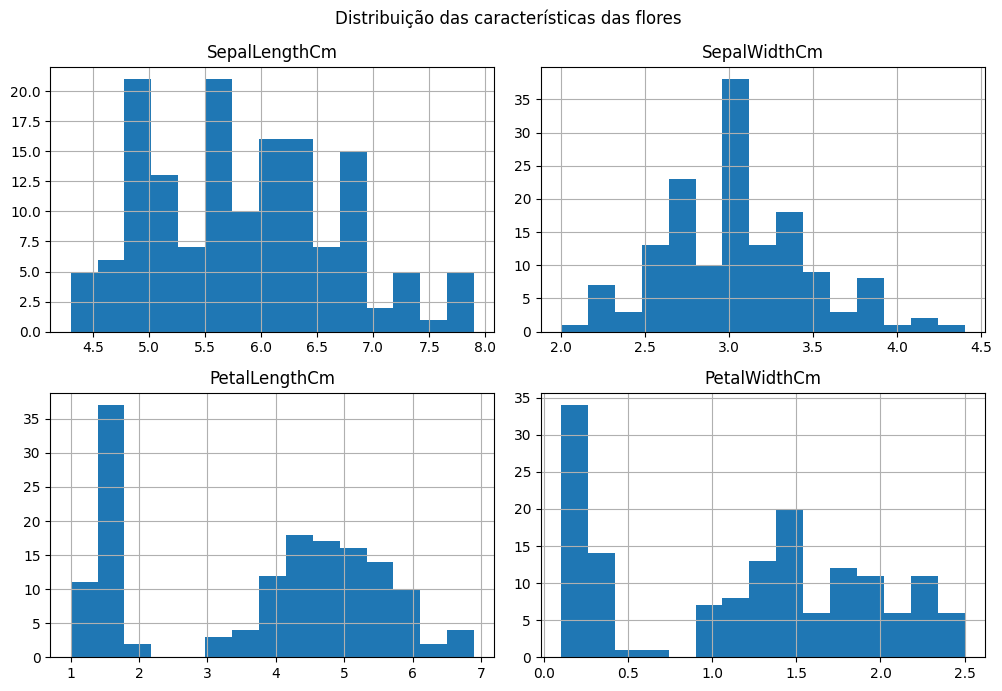

In [9]:
# Selecionando somente as quatro características que representam medidas das flores
caracteristicas = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]

# Criando histogramas para visualizar a distribuição de cada característica
df[caracteristicas].hist(bins=15, figsize=(10, 7))

# Adicionando um título geral aos gráficos
plt.suptitle("Distribuição das características das flores")

# Ajustando o espaço entre os gráficos para melhorar a visualização
plt.tight_layout()

# Exibindo os histogramas
plt.show()

### Relação entre as características e as espécies

Os histogramas permitiram observar como as quatro medidas das flores estão distribuídas. Foi possível perceber que algumas características, principalmente as relacionadas às pétalas, apresentam grupos de valores mais separados.

Para visualizar melhor essas diferenças, vamos comparar o comprimento e a largura das pétalas de cada espécie em um gráfico de dispersão.

Nesse tipo de gráfico, cada ponto representa uma flor do dataset. A posição do ponto é definida pelas medidas da pétala, enquanto as espécies serão representadas separadamente. Isso ajuda a perceber visualmente se existem regiões diferentes para cada espécie.

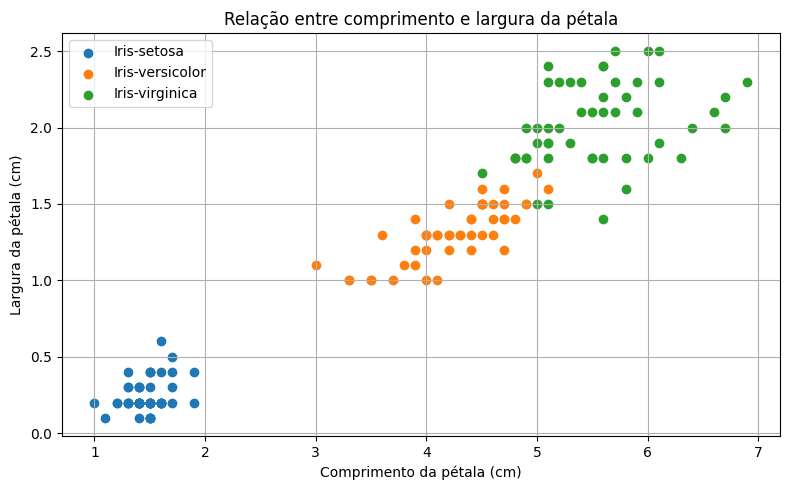

In [10]:
# Criando uma lista com as três espécies existentes no dataset
especies = df["Species"].unique()

# Percorrendo cada espécie para representar seus dados separadamente
for especie in especies:

    # Selecionando somente as flores pertencentes à espécie atual
    dados_especie = df[df["Species"] == especie]

    # Criando os pontos do gráfico utilizando
    # o comprimento e a largura da pétala
    plt.scatter(
        dados_especie["PetalLengthCm"],
        dados_especie["PetalWidthCm"],
        label=especie
    )

# Adicionando um título ao gráfico
plt.title("Relação entre comprimento e largura da pétala")

# Identificando o eixo horizontal
plt.xlabel("Comprimento da pétala (cm)")

# Identificando o eixo vertical
plt.ylabel("Largura da pétala (cm)")

# Adicionando a legenda para identificar cada espécie
plt.legend()

# Adicionando uma grade para facilitar a leitura dos valores
plt.grid(True)

# Ajustando automaticamente os elementos do gráfico
plt.tight_layout()

# Exibindo o gráfico
plt.show()

### Interpretação do gráfico

Observando o gráfico, é possível perceber uma separação bem clara da Iris-setosa em relação às outras duas espécies. Suas pétalas apresentam valores menores tanto no comprimento quanto na largura.

A Iris-versicolor e a Iris-virginica também formam grupos diferentes, porém existe uma pequena região em que alguns pontos ficam próximos ou se sobrepõem.

Essa análise mostra que o comprimento e a largura das pétalas são características importantes para diferenciar as espécies e podem contribuir bastante para o treinamento do modelo SVM.

### Relação entre comprimento e largura da sépala

Depois de observar que as medidas das pétalas apresentam diferenças importantes entre as espécies, vamos realizar a mesma comparação utilizando as medidas das sépalas.

Neste gráfico, vamos relacionar o comprimento e a largura da sépala de cada flor. Assim, podemos verificar se essas características também apresentam uma separação visível entre as três espécies.

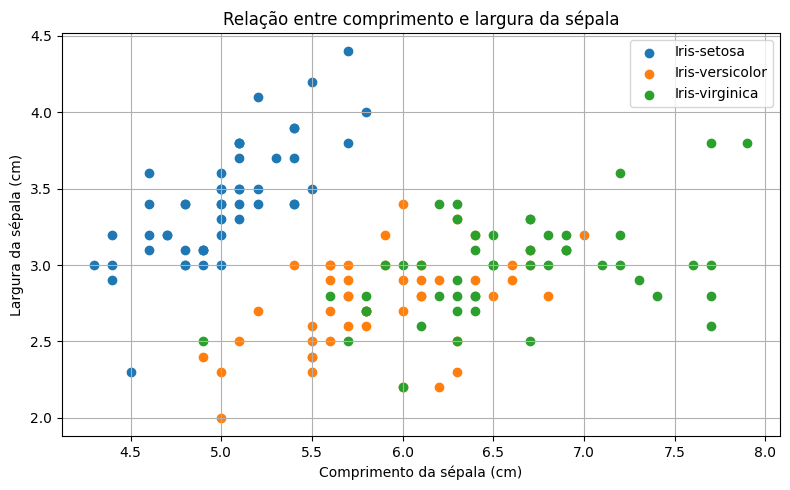

In [11]:
# Percorrendo cada uma das espécies existentes no dataset
for especie in especies:

    # Selecionando somente os registros pertencentes à espécie atual
    dados_especie = df[df["Species"] == especie]

    # Criando os pontos do gráfico utilizando
    # o comprimento e a largura da sépala
    plt.scatter(
        dados_especie["SepalLengthCm"],
        dados_especie["SepalWidthCm"],
        label=especie
    )

# Adicionando um título para identificar o gráfico
plt.title("Relação entre comprimento e largura da sépala")

# Identificando o eixo horizontal
plt.xlabel("Comprimento da sépala (cm)")

# Identificando o eixo vertical
plt.ylabel("Largura da sépala (cm)")

# Adicionando a legenda para identificar cada espécie
plt.legend()

# Adicionando uma grade para facilitar a visualização dos valores
plt.grid(True)

# Ajustando os elementos do gráfico
plt.tight_layout()

# Exibindo o gráfico
plt.show()

### Interpretação do gráfico das sépalas

Ao observar as medidas das sépalas, podemos perceber que existe uma separação menor entre as espécies quando comparamos com o gráfico das pétalas.

A Iris-setosa ainda apresenta uma região relativamente distinta, mas existe uma sobreposição maior entre a Iris-versicolor e a Iris-virginica.

Comparando os dois gráficos, as medidas das pétalas parecem apresentar uma separação mais clara entre as espécies. Mesmo assim, as quatro características serão utilizadas no treinamento do SVM, permitindo que o modelo considere todas essas informações durante a classificação.


## 5. Preparação dos dados para o modelo

Depois de explorar e entender melhor o dataset, podemos começar a preparar os dados que serão utilizados pelo modelo SVM.

Para o treinamento, vamos separar as informações em duas partes. A variável `X` vai armazenar as características das flores, ou seja, as medidas de comprimento e largura das sépalas e pétalas. Já a variável `y` vai armazenar a espécie correspondente a cada flor.

A coluna `Id` não será utilizada no treinamento, pois ela serve apenas para identificar cada registro e não representa uma característica da flor.

In [12]:
# Selecionando as quatro características das flores
# que serão utilizadas pelo modelo para realizar a classificação
X = df[
    [
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm"
    ]
]

# Selecionando a espécie de cada flor
# Essa será a informação que o modelo deverá aprender a prever
y = df["Species"]

# Mostrando as primeiras linhas das características selecionadas
print("Características utilizadas pelo modelo:")
print(X.head())

# Mostrando as primeiras espécies correspondentes
print("\nEspécies que serão previstas:")
print(y.head())

Características utilizadas pelo modelo:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

Espécies que serão previstas:
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object


### Divisão dos dados em treinamento e teste

Agora que definimos as características que serão utilizadas pelo modelo e a informação que queremos prever, precisamos separar os dados em dois grupos: treinamento e teste.

Vamos utilizar 80% dos dados para treinar o modelo e os outros 20% para avaliar seu desempenho. Dessa forma, o SVM será testado com dados que não foram utilizados durante o treinamento.

Também vamos manter a mesma proporção das três espécies nos conjuntos de treino e teste, já que o dataset possui a mesma quantidade de exemplos para cada espécie.

In [13]:
# Separando os dados em conjuntos de treinamento e teste
# 80% dos registros serão utilizados para treinamento
# e 20% serão utilizados para testar o modelo
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Mostrando a quantidade de registros separados para treinamento
print("Quantidade de dados para treinamento:", X_train.shape[0])

# Mostrando a quantidade de registros separados para teste
print("Quantidade de dados para teste:", X_test.shape[0])

Quantidade de dados para treinamento: 120
Quantidade de dados para teste: 30


### Padronização dos dados

Antes de treinar o SVM, vamos padronizar as características das flores utilizando o StandardScaler.

A padronização coloca as variáveis em uma escala semelhante, evitando que uma característica tenha uma influência maior apenas por possuir valores numericamente maiores.

Para evitar que informações do conjunto de teste sejam utilizadas durante o treinamento, o ajuste da padronização será feito somente com os dados de treino. Depois, a mesma transformação será aplicada aos dados de teste.

In [14]:
# Criando o objeto responsável pela padronização dos dados
scaler = sklearn.preprocessing.StandardScaler()

# Aprendendo a média e o desvio padrão somente com os dados de treinamento
# e, em seguida, realizando a padronização desses dados
X_train_padronizado = scaler.fit_transform(X_train)

# Aplicando nos dados de teste a mesma padronização
# que foi aprendida utilizando os dados de treinamento
X_test_padronizado = scaler.transform(X_test)

# Mostrando as primeiras linhas dos dados de treinamento
# depois da padronização
print("Primeiros dados de treinamento após a padronização:")
print(X_train_padronizado[:5])

Primeiros dados de treinamento após a padronização:
[[-1.72156775 -0.32483982 -1.34703555 -1.32016847]
 [-1.12449223 -1.22612948  0.41429037  0.65186742]
 [ 1.14439475 -0.55016223  0.58474127  0.25746024]
 [-1.12449223  0.12580502 -1.29021859 -1.45163753]
 [-0.40800161 -1.22612948  0.13020555  0.12599118]]


## 6. Criação e treinamento do modelo SVM

Com os dados preparados, podemos iniciar o treinamento do modelo de classificação.

Nesta atividade será utilizado exclusivamente o algoritmo Support Vector Machine (SVM). O objetivo do SVM é encontrar uma separação entre as classes a partir das características fornecidas durante o treinamento.

Neste primeiro modelo, vamos utilizar o kernel linear. Essa configuração busca separar as classes utilizando limites lineares e será nosso primeiro teste para verificar o desempenho do SVM no dataset Iris.

O modelo será treinado utilizando somente os dados que foram separados anteriormente para treinamento.

In [15]:
# Criando o modelo de classificação utilizando Support Vector Machine
# O kernel linear será utilizado neste primeiro modelo
modelo_svm = sklearn.svm.SVC(
    kernel="linear",
    C=1.0
)

# Treinando o modelo utilizando os dados de treinamento padronizados
# e as espécies correspondentes a cada flor
modelo_svm.fit(
    X_train_padronizado,
    y_train
)

# Mostrando uma mensagem para confirmar que o treinamento foi concluído
print("Modelo SVM treinado com sucesso!")

Modelo SVM treinado com sucesso!


### Realizando as previsões

Depois de treinar o SVM, vamos utilizar os dados de teste para realizar as previsões.

Esses dados não foram utilizados durante o treinamento. Dessa forma, podemos comparar as respostas fornecidas pelo modelo com as espécies verdadeiras e verificar se ele conseguiu aprender a diferenciar as flores corretamente.

In [16]:
# Utilizando o modelo SVM treinado para prever as espécies
# das 30 flores que foram separadas para o conjunto de teste
y_pred = modelo_svm.predict(X_test_padronizado)

# Mostrando as espécies que foram previstas pelo modelo
print("Espécies previstas pelo SVM:")
print(y_pred)

# Mostrando as espécies verdadeiras das flores
# para podermos comparar com as previsões realizadas
print("\nEspécies verdadeiras:")
print(y_test.values)

Espécies previstas pelo SVM:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa']

Espécies verdadeiras:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolo

## 7. Avaliação do modelo SVM

Depois de realizar as previsões, precisamos avaliar o desempenho do modelo e verificar quantas classificações foram realizadas corretamente.

Para isso, vamos utilizar algumas métricas de classificação, como acurácia, precisão, recall e F1-score. Essas métricas ajudam a analisar o desempenho do SVM de uma forma mais completa, sem considerar apenas a quantidade total de acertos.

Primeiro, vamos calcular a acurácia do modelo, comparando as espécies previstas pelo SVM com as espécies verdadeiras do conjunto de teste.

In [17]:
# Calculando a acurácia do modelo ao comparar
# as respostas verdadeiras com as previsões realizadas pelo SVM
acuracia = sklearn.metrics.accuracy_score(
    y_test,
    y_pred
)

# Mostrando a acurácia em formato decimal
print("Acurácia do modelo:", acuracia)

# Mostrando também a acurácia em porcentagem
print("Acurácia em porcentagem:", round(acuracia * 100, 2), "%")

Acurácia do modelo: 1.0
Acurácia em porcentagem: 100.0 %


### Relatório de classificação

Além da acurácia, vamos analisar outras métricas importantes para entender melhor o desempenho do modelo em cada uma das espécies.

A precisão indica, entre as previsões realizadas para uma determinada espécie, quantas estavam corretas. O recall mostra a capacidade do modelo de encontrar corretamente os exemplos daquela espécie. Já o F1-score busca um equilíbrio entre precisão e recall.

Essas métricas permitem observar o comportamento do SVM individualmente para Iris-setosa, Iris-versicolor e Iris-virginica.

In [18]:
# Gerando o relatório de classificação do modelo
# O relatório apresenta precision, recall e F1-score
# separadamente para cada espécie
relatorio = sklearn.metrics.classification_report(
    y_test,
    y_pred
)

# Mostrando o relatório completo
print("Relatório de classificação:")
print(relatorio)

Relatório de classificação:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



### Interpretação dos resultados

O modelo SVM apresentou um ótimo desempenho no conjunto de teste, alcançando 100% de acurácia nas 30 amostras utilizadas para avaliação.

Ao analisar cada espécie separadamente, os valores de precision, recall e F1-score também foram iguais a 1.00 para Iris-setosa, Iris-versicolor e Iris-virginica.

Isso significa que, neste conjunto de teste, o modelo conseguiu classificar corretamente todas as flores, sem apresentar erros entre as três espécies.

Apesar do resultado de 100%, ele representa o desempenho obtido nesta divisão específica dos dados. Por isso, outras formas de avaliação, como a matriz de confusão e a validação cruzada, também podem ajudar a analisar o comportamento do modelo.

### Matriz de confusão

Para visualizar melhor os acertos e possíveis erros do modelo, vamos utilizar uma matriz de confusão.

A matriz compara as espécies verdadeiras com as espécies previstas pelo SVM. Dessa forma, conseguimos identificar quantas flores de cada espécie foram classificadas corretamente e se ocorreu alguma confusão entre as classes.

In [19]:
# Criando a matriz de confusão ao comparar
# as espécies verdadeiras com as previsões realizadas pelo SVM
matriz_confusao = sklearn.metrics.confusion_matrix(
    y_test,
    y_pred
)

# Mostrando os valores da matriz de confusão
print("Matriz de confusão:")
print(matriz_confusao)

Matriz de confusão:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


### Visualização da matriz de confusão

Para facilitar a interpretação dos resultados, também vamos representar a matriz de confusão em forma de gráfico.

Essa visualização permite identificar de maneira mais clara onde estão os acertos e possíveis erros de classificação do modelo.

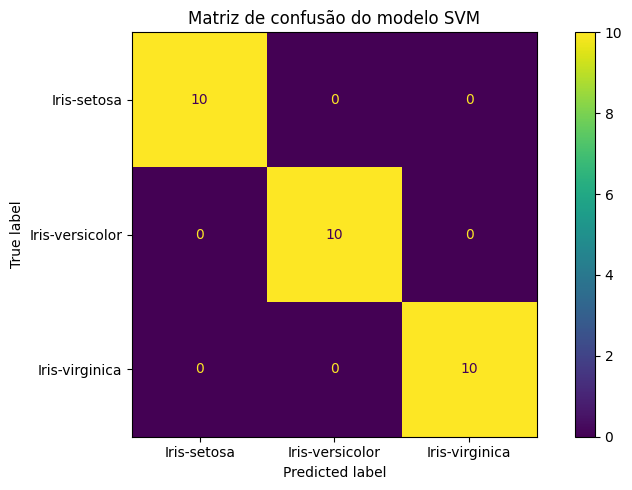

In [20]:
# Criando a visualização da matriz de confusão
# utilizando diretamente as previsões realizadas pelo modelo
visualizacao_matriz = sklearn.metrics.ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao,
    display_labels=modelo_svm.classes_
)

# Gerando o gráfico da matriz de confusão
visualizacao_matriz.plot()

# Adicionando um título ao gráfico
plt.title("Matriz de confusão do modelo SVM")

# Ajustando os elementos do gráfico
plt.tight_layout()

# Exibindo o resultado
plt.show()

## 8. Validação cruzada

Até o momento, avaliamos o modelo utilizando uma única divisão dos dados em treinamento e teste. Como o resultado obtido foi de 100% de acurácia, também vamos utilizar a validação cruzada para ter uma visão mais completa do desempenho do SVM.

Na validação cruzada, os dados são divididos em diferentes partes e o modelo é treinado e avaliado várias vezes. Neste caso, vamos utilizar 5 divisões (folds).

Para evitar que os dados utilizados na avaliação influenciem a padronização, vamos utilizar um Pipeline. Dessa forma, o StandardScaler será aplicado dentro de cada etapa da validação cruzada antes do treinamento do SVM.

In [21]:
# Criando um Pipeline para realizar a padronização
# e o treinamento do SVM dentro de cada etapa da validação cruzada
pipeline_svm = sklearn.pipeline.Pipeline([

    # Padronizando os dados antes do treinamento
    ("padronizacao", sklearn.preprocessing.StandardScaler()),

    # Criando o modelo SVM utilizando o kernel linear
    ("svm", sklearn.svm.SVC(kernel="linear", C=1.0))
])

# Realizando a validação cruzada com 5 divisões
# O modelo será treinado e avaliado em diferentes partes do dataset
resultados_cv = sklearn.model_selection.cross_val_score(
    pipeline_svm,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

# Convertendo cada resultado da validação cruzada para porcentagem
acuracias_porcentagem = []

# Percorrendo cada acurácia encontrada
for resultado in resultados_cv:

    # Multiplicando por 100 e formatando com duas casas decimais
    porcentagem = f"{resultado * 100:.2f}%"

    # Adicionando o resultado formatado na lista
    acuracias_porcentagem.append(porcentagem)

# Calculando a média das acurácias
media_cv = resultados_cv.mean()

# Mostrando as acurácias de forma organizada
print("Acurácias:")
print(" | ".join(acuracias_porcentagem))

# Mostrando a média final também em porcentagem
print(f"\nMédia: {media_cv * 100:.2f}%")

Acurácias:
96.67% | 100.00% | 93.33% | 93.33% | 100.00%

Média: 96.67%


### Interpretação da validação cruzada

Na validação cruzada com 5 divisões, o modelo apresentou acurácias diferentes em cada avaliação, variando entre aproximadamente 93,33% e 100%.

A média obtida foi de 96,67%, mostrando que o SVM manteve um bom desempenho mesmo quando foi treinado e testado com diferentes partes do dataset.

Esse resultado complementa a acurácia de 100% obtida anteriormente no conjunto de teste. Enquanto aquela avaliação utilizou apenas uma divisão dos dados, a validação cruzada mostra que o desempenho do modelo pode variar dependendo das amostras utilizadas no treinamento e no teste.

Mesmo com essa variação, a média de 96,67% indica que o modelo conseguiu classificar as espécies do dataset Iris com uma boa capacidade de generalização.

## 9. Experimento 2 — SVM não linear com kernel RBF

Depois de avaliar o SVM com kernel linear, vamos realizar um novo experimento utilizando o kernel RBF.

O kernel RBF permite que o SVM trabalhe com separações mais flexíveis entre as classes. Isso pode ser útil quando os dados não conseguem ser separados de forma adequada utilizando apenas uma fronteira linear.

Para manter uma comparação justa, vamos utilizar os mesmos dados de treinamento e teste do experimento anterior, alterando apenas o kernel utilizado pelo SVM.

In [22]:
# Criando o segundo modelo utilizando Support Vector Machine
# Desta vez, vamos utilizar o kernel RBF
modelo_svm_rbf = sklearn.svm.SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

# Treinando o modelo RBF utilizando os dados
# de treinamento que já foram padronizados anteriormente
modelo_svm_rbf.fit(
    X_train_padronizado,
    y_train
)

# Realizando as previsões com os dados de teste
# utilizando o modelo SVM com kernel RBF
y_pred_rbf = modelo_svm_rbf.predict(
    X_test_padronizado
)

# Mostrando uma mensagem para confirmar
# que o treinamento foi realizado corretamente
print("Modelo SVM com kernel RBF treinado com sucesso!")

Modelo SVM com kernel RBF treinado com sucesso!


## 10. Avaliação do SVM com kernel RBF

Agora que o modelo SVM com kernel RBF foi treinado e realizou as previsões, vamos avaliar o seu desempenho.

Vamos utilizar as mesmas métricas usadas anteriormente no modelo com kernel linear. Dessa forma, poderemos observar a acurácia, precision, recall e F1-score do novo modelo e, mais adiante, comparar os resultados dos dois experimentos.

In [23]:
# Calculando a acurácia do modelo SVM com kernel RBF
# comparando as previsões com as respostas verdadeiras
acuracia_rbf = sklearn.metrics.accuracy_score(
    y_test,
    y_pred_rbf
)

# Mostrando a acurácia em formato de porcentagem
print(
    "Acurácia do SVM com kernel RBF:",
    round(acuracia_rbf * 100, 2),
    "%"
)

# Gerando o relatório de classificação
# para analisar precision, recall e F1-score de cada espécie
relatorio_rbf = sklearn.metrics.classification_report(
    y_test,
    y_pred_rbf
)

# Mostrando o relatório completo
print("\nRelatório de classificação:")
print(relatorio_rbf)

Acurácia do SVM com kernel RBF: 96.67 %

Relatório de classificação:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



### Matriz de confusão do modelo RBF

Além das métricas apresentadas anteriormente, vamos utilizar a matriz de confusão para visualizar os acertos e erros do modelo.

Ela permite observar quantas flores de cada espécie foram classificadas corretamente e em quais situações o modelo apresentou dificuldade.

Matriz de confusão do SVM com kernel RBF:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


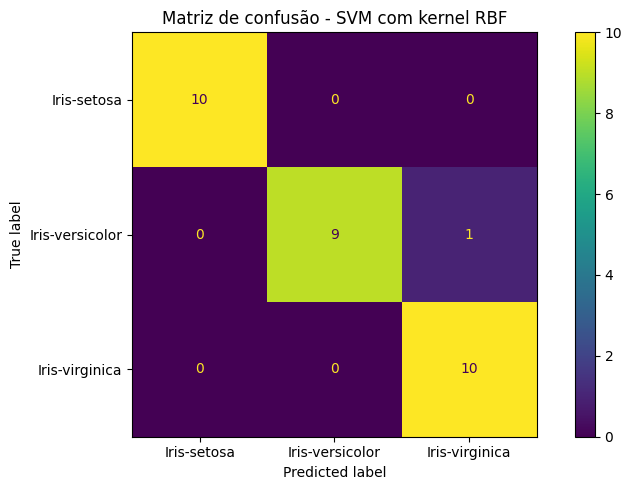

In [24]:
# Criando a matriz de confusão do modelo SVM com kernel RBF
# comparando as espécies verdadeiras com as previsões realizadas
matriz_confusao_rbf = sklearn.metrics.confusion_matrix(
    y_test,
    y_pred_rbf
)

# Mostrando os valores da matriz de confusão
print("Matriz de confusão do SVM com kernel RBF:")
print(matriz_confusao_rbf)

# Criando uma visualização gráfica da matriz de confusão
visualizacao_rbf = sklearn.metrics.ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao_rbf,
    display_labels=modelo_svm_rbf.classes_
)

# Gerando o gráfico
visualizacao_rbf.plot()

# Adicionando um título para identificar o gráfico
plt.title("Matriz de confusão - SVM com kernel RBF")

# Ajustando os elementos do gráfico
plt.tight_layout()

# Exibindo o gráfico
plt.show()

## 11. Validação cruzada do SVM com kernel RBF

Depois de avaliar o modelo RBF utilizando o conjunto de teste, vamos realizar também a validação cruzada com 5 divisões.

Essa etapa permite avaliar o modelo em diferentes partes do dataset, evitando que nossa análise dependa apenas de uma única divisão entre treinamento e teste.

Assim como fizemos anteriormente, vamos utilizar um Pipeline para realizar a padronização dos dados dentro de cada etapa da validação cruzada.

In [25]:
# Criando um Pipeline para realizar a padronização
# e o treinamento do SVM com kernel RBF
pipeline_svm_rbf = sklearn.pipeline.Pipeline([

    # Padronizando os dados antes de cada treinamento
    ("padronizacao", sklearn.preprocessing.StandardScaler()),

    # Criando o modelo SVM utilizando o kernel RBF
    ("svm", sklearn.svm.SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale"
    ))
])

# Realizando a validação cruzada utilizando 5 divisões
# A acurácia será calculada em cada uma dessas divisões
resultados_cv_rbf = sklearn.model_selection.cross_val_score(
    pipeline_svm_rbf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

# Criando uma lista para armazenar
# as acurácias já convertidas para porcentagem
acuracias_rbf = []

# Percorrendo os resultados encontrados na validação cruzada
for resultado in resultados_cv_rbf:

    # Convertendo cada resultado para porcentagem
    porcentagem = f"{resultado * 100:.2f}"

    # Retirando zeros desnecessários
    # Por exemplo: 100.00 será mostrado apenas como 100
    porcentagem = porcentagem.rstrip("0").rstrip(".")

    # Trocando o ponto pela vírgula
    # para deixar o resultado no padrão brasileiro
    porcentagem = porcentagem.replace(".", ",")

    # Adicionando o símbolo de porcentagem
    acuracias_rbf.append(porcentagem + "%")

# Calculando a média das cinco acurácias
media_cv_rbf = resultados_cv_rbf.mean()

# Formatando a média com duas casas decimais
# e utilizando vírgula no lugar do ponto
media_rbf_formatada = f"{media_cv_rbf * 100:.2f}".replace(".", ",")

# Mostrando os resultados de forma organizada
print("Acurácias do SVM com kernel RBF:")
print(" | ".join(acuracias_rbf))

# Mostrando a média final
print("\nMédia:", media_rbf_formatada + "%")

Acurácias do SVM com kernel RBF:
96,67% | 96,67% | 96,67% | 93,33% | 100%

Média: 96,67%


## 12. Comparação entre SVM Linear e SVM RBF

Depois de avaliar os dois modelos separadamente, vamos comparar os resultados obtidos pelo SVM com kernel linear e pelo SVM com kernel RBF.

Para realizar essa comparação, vamos observar a acurácia obtida no conjunto de teste e também a média encontrada na validação cruzada.

Essa comparação ajuda a entender como a escolha do kernel pode influenciar o desempenho do SVM no dataset Iris.

In [26]:
# Calculando novamente a acurácia do modelo com kernel linear
# utilizando as previsões realizadas anteriormente
acuracia_linear = sklearn.metrics.accuracy_score(
    y_test,
    y_pred
)

# A acurácia do modelo RBF já foi calculada anteriormente
# e está armazenada na variável acuracia_rbf

# Criando uma tabela para organizar
# os resultados dos dois modelos
comparacao_modelos = pd.DataFrame({
    "Modelo": [
        "SVM Linear",
        "SVM RBF"
    ],

    # Convertendo as acurácias do conjunto de teste
    # para porcentagem
    "Acurácia no teste (%)": [
        round(acuracia_linear * 100, 2),
        round(acuracia_rbf * 100, 2)
    ],

    # Convertendo as médias da validação cruzada
    # para porcentagem
    "Média validação cruzada (%)": [
        round(media_cv * 100, 2),
        round(media_cv_rbf * 100, 2)
    ]
})

# Exibindo a tabela com a comparação
comparacao_modelos

,Modelo,Acurácia no teste (%),Média validação cruzada (%)
0,SVM Linear,100.00,96.67
1,SVM RBF,96.67,96.67


### Análise da comparação

A comparação permite observar o desempenho dos dois kernels utilizando os mesmos dados.

O SVM Linear apresentou um ótimo resultado no conjunto de teste, enquanto o SVM com kernel RBF também apresentou uma alta taxa de acertos.

A validação cruzada complementa essa análise, pois mostra o comportamento dos modelos em diferentes divisões do dataset. Dessa forma, podemos perceber que os dois modelos apresentam bom desempenho para a classificação das espécies do dataset Iris.


## 13. Testes com outras configurações do SVM

Depois de comparar o SVM Linear com o SVM utilizando kernel RBF, vamos realizar alguns experimentos com outras configurações.

Primeiro, vamos testar o kernel polinomial. Depois, também vamos modificar os valores dos parâmetros C e gamma do kernel RBF.

O objetivo desses testes é observar como diferentes configurações podem influenciar o desempenho do SVM na classificação das espécies do dataset Iris.

### Teste 1 — Kernel polinomial

Neste primeiro teste, vamos utilizar o kernel polinomial com grau 3.

Vamos treinar o modelo utilizando os mesmos dados utilizados anteriormente e calcular sua acurácia. Também vamos gerar a matriz de confusão para observar os acertos e erros do modelo e comparar seu resultado com os kernels Linear e RBF.

Acurácia do SVM com kernel polinomial: 90.0 %

Matriz de confusão:
[[10  0  0]
 [ 0 10  0]
 [ 0  3  7]]


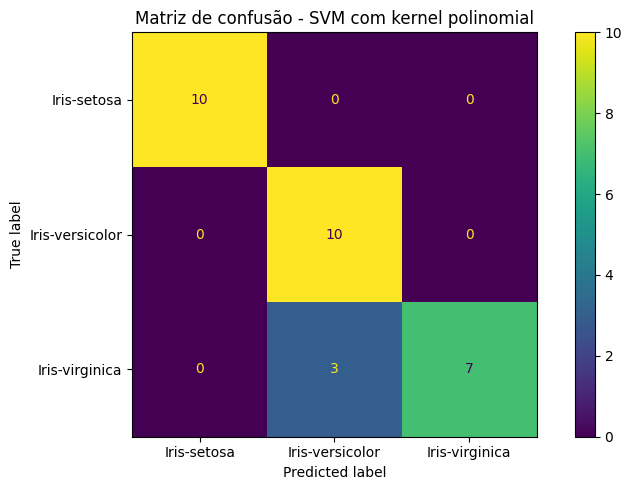

In [27]:
# Criando o modelo SVM utilizando o kernel polinomial
# O degree=3 indica que será utilizado um polinômio de grau 3
modelo_svm_poly = sklearn.svm.SVC(
    kernel="poly",
    degree=3,
    C=1.0,
    gamma="scale"
)

# Treinando o modelo polinomial utilizando
# os dados de treinamento padronizados
modelo_svm_poly.fit(
    X_train_padronizado,
    y_train
)

# Realizando as previsões utilizando
# os dados que foram separados para teste
y_pred_poly = modelo_svm_poly.predict(
    X_test_padronizado
)

# Calculando a acurácia do modelo polinomial
acuracia_poly = sklearn.metrics.accuracy_score(
    y_test,
    y_pred_poly
)

# Mostrando a acurácia em porcentagem
print(
    "Acurácia do SVM com kernel polinomial:",
    round(acuracia_poly * 100, 2),
    "%"
)

# Criando a matriz de confusão do modelo polinomial
matriz_confusao_poly = sklearn.metrics.confusion_matrix(
    y_test,
    y_pred_poly
)

# Mostrando os valores encontrados
print("\nMatriz de confusão:")
print(matriz_confusao_poly)

# Criando a visualização da matriz de confusão
visualizacao_poly = sklearn.metrics.ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao_poly,
    display_labels=modelo_svm_poly.classes_
)

# Gerando o gráfico
visualizacao_poly.plot()

# Adicionando um título ao gráfico
plt.title("Matriz de confusão - SVM com kernel polinomial")

# Ajustando os elementos do gráfico
plt.tight_layout()

# Exibindo o gráfico
plt.show()

### Teste 2 — Diferentes valores de C

Agora vamos observar como diferentes valores do parâmetro C podem influenciar o desempenho do SVM com kernel RBF.

Para isso, vamos testar os valores 0.1, 1, 10 e 100. Todos os modelos serão treinados e avaliados utilizando os mesmos dados, permitindo comparar os resultados de maneira mais justa.

Ao final, vamos observar qual valor apresentou a melhor acurácia no conjunto de teste.

In [28]:
# Criando uma lista com os valores de C
# que serão testados no modelo SVM com kernel RBF
valores_c = [0.1, 1, 10, 100]

# Criando uma lista vazia para armazenar
# os resultados encontrados em cada teste
resultados_c = []

# Percorrendo cada valor de C definido anteriormente
for valor_c in valores_c:

    # Criando um novo modelo SVM com kernel RBF
    # utilizando o valor atual de C
    modelo_teste_c = sklearn.svm.SVC(
        kernel="rbf",
        C=valor_c,
        gamma="scale"
    )

    # Treinando o modelo utilizando
    # os dados de treinamento padronizados
    modelo_teste_c.fit(
        X_train_padronizado,
        y_train
    )

    # Realizando as previsões com os dados de teste
    previsao_c = modelo_teste_c.predict(
        X_test_padronizado
    )

    # Calculando a acurácia obtida
    # com o valor atual de C
    acuracia_c = sklearn.metrics.accuracy_score(
        y_test,
        previsao_c
    )

    # Guardando o valor de C e sua respectiva
    # acurácia para comparar depois
    resultados_c.append({
        "Valor de C": valor_c,
        "Acurácia (%)": round(acuracia_c * 100, 2)
    })

# Transformando os resultados em uma tabela
# para facilitar a comparação
tabela_resultados_c = pd.DataFrame(resultados_c)

# Exibindo a tabela com os resultados
tabela_resultados_c

,Valor de C,Acurácia (%)
0,0.1,90.00
1,1.0,96.67
2,10.0,96.67
3,100.0,96.67


### Teste 3 — Diferentes valores de gamma

Para finalizar os experimentos, vamos testar diferentes valores do parâmetro gamma utilizando o kernel RBF.

O gamma influencia o comportamento do modelo durante a criação da fronteira de decisão. Neste teste, vamos utilizar as configurações "scale", "auto", 0.1 e 1.

Vamos manter os outros parâmetros iguais e comparar a acurácia obtida em cada configuração.

In [29]:
# Criando uma lista com os diferentes valores
# de gamma que serão testados no kernel RBF
valores_gamma = ["scale", "auto", 0.1, 1]

# Criando uma lista vazia para armazenar
# os resultados encontrados em cada teste
resultados_gamma = []

# Percorrendo cada valor de gamma
for valor_gamma in valores_gamma:

    # Criando um novo modelo SVM com kernel RBF
    # utilizando o valor atual de gamma
    modelo_teste_gamma = sklearn.svm.SVC(
        kernel="rbf",
        C=1.0,
        gamma=valor_gamma
    )

    # Treinando o modelo utilizando
    # os dados de treinamento padronizados
    modelo_teste_gamma.fit(
        X_train_padronizado,
        y_train
    )

    # Realizando as previsões utilizando
    # os dados separados para teste
    previsao_gamma = modelo_teste_gamma.predict(
        X_test_padronizado
    )

    # Calculando a acurácia obtida
    # com a configuração atual de gamma
    acuracia_gamma = sklearn.metrics.accuracy_score(
        y_test,
        previsao_gamma
    )

    # Guardando o valor de gamma e
    # a acurácia encontrada nesse teste
    resultados_gamma.append({
        "Gamma": str(valor_gamma),
        "Acurácia (%)": round(acuracia_gamma * 100, 2)
    })

# Transformando os resultados em uma tabela
# para facilitar a comparação
tabela_resultados_gamma = pd.DataFrame(
    resultados_gamma
)

# Exibindo a tabela com os resultados
tabela_resultados_gamma

,Gamma,Acurácia (%)
0,scale,96.67
1,auto,96.67
2,0.1,96.67
3,1,93.33


## 14. Questões de fixação

### Questões conceituais

**1. O que caracteriza um problema de classificação supervisionada?**

É um problema em que o modelo aprende utilizando dados que já possuem uma classe conhecida. A partir desses exemplos, ele tenta identificar padrões para conseguir classificar novos dados.

**2. No dataset Iris, quais são as variáveis de entrada e qual é a variável-alvo?**

As variáveis de entrada são o comprimento e a largura da sépala e o comprimento e a largura da pétala. A variável-alvo é a espécie da flor.

**3. Qual é a ideia principal do SVM ao construir uma fronteira de decisão?**

A ideia principal do SVM é encontrar uma fronteira que consiga separar as classes da melhor maneira possível, buscando manter uma boa distância entre essa fronteira e os exemplos mais próximos de cada classe.

**4. O que são vetores de suporte?**

São os pontos que ficam mais próximos da fronteira de decisão. Esses pontos possuem uma influência importante na definição da separação realizada pelo SVM.

**5. Qual é a diferença geral entre um SVM linear e um SVM não linear?**

O SVM linear utiliza uma fronteira linear para separar as classes. Já o SVM não linear utiliza kernels, como RBF ou polinomial, permitindo criar fronteiras mais flexíveis para dados que não conseguem ser separados facilmente de forma linear.

**6. Por que a padronização é importante para SVM?**

Porque o SVM trabalha com distâncias entre os dados. A padronização coloca as características em escalas semelhantes e evita que uma variável tenha mais influência no modelo apenas por possuir valores maiores.

**7. O que significa o parâmetro C em termos intuitivos?**

O parâmetro C controla o quanto o modelo tolera erros durante o treinamento. Dependendo do valor utilizado, o modelo pode ser mais ou menos rígido na tentativa de classificar corretamente os dados.

**8. Qual é o papel do gamma em kernels como o rbf?**

O gamma controla a influência que cada ponto possui na criação da fronteira de decisão. Dependendo do valor utilizado, a fronteira criada pelo modelo pode se tornar mais simples ou mais complexa.


### Questões de interpretação

**9. O SVM linear teve desempenho satisfatório? Como você justifica sua resposta?**

Sim. O SVM linear apresentou um desempenho muito bom. No conjunto de teste utilizado no experimento, ele alcançou 100% de acurácia. Além disso, na validação cruzada apresentou uma média de 96,67%, mostrando que o modelo conseguiu manter um bom desempenho em diferentes divisões dos dados.

**10. O kernel rbf melhorou os resultados em relação ao modelo linear?**

Não no conjunto de teste utilizado. O SVM linear apresentou 100% de acurácia, enquanto o SVM com kernel RBF apresentou 96,67%. Porém, na validação cruzada, os dois modelos apresentaram uma média de 96,67%, mostrando que o desempenho geral dos dois foi bastante parecido.

**11. Em quais espécies ocorreram mais confusões?**

As principais confusões ocorreram entre Iris-versicolor e Iris-virginica. No modelo RBF ocorreu apenas um erro de classificação entre essas espécies, enquanto a Iris-setosa foi classificada corretamente em todas as amostras.

**12. O que a validação cruzada acrescenta em relação a uma única divisão treino/teste?**

A validação cruzada permite avaliar o modelo utilizando diferentes divisões dos dados. Dessa forma, conseguimos ter uma visão mais confiável do desempenho do modelo e não ficamos dependendo apenas do resultado de uma única divisão entre treino e teste.

**13. Se dois modelos tiverem desempenho muito parecido, por que pode ser melhor escolher o mais simples?**

Porque um modelo mais simples pode ser mais fácil de entender, configurar e utilizar. Se dois modelos apresentam resultados praticamente iguais, nem sempre existe vantagem em utilizar uma solução mais complexa.


### Questões práticas

**14. O que aconteceu quando você testou o kernel polinomial?**

O kernel polinomial apresentou uma acurácia de 90%. Ele classificou corretamente todas as amostras de Iris-setosa e Iris-versicolor, mas apresentou dificuldade com a Iris-virginica. Das 10 amostras de Iris-virginica, 7 foram classificadas corretamente e 3 foram confundidas com Iris-versicolor. Portanto, nesse experimento, o kernel polinomial teve um desempenho inferior aos modelos Linear e RBF.

**15. Qual valor de C pareceu mais adequado no seu experimento?**

Os valores de C iguais a 1, 10 e 100 apresentaram a mesma acurácia de 96,67%, enquanto C igual a 0.1 apresentou 90%. Como C = 1 conseguiu alcançar a maior acurácia e teve o mesmo resultado dos valores maiores, ele parece ser uma escolha adequada para este experimento.

**16. Alterações em gamma mudaram muito o resultado?**

As alterações em gamma não mudaram muito o resultado na maioria dos testes. Os valores "scale", "auto" e 0.1 apresentaram a mesma acurácia de 96,67%. Já gamma igual a 1 apresentou uma pequena queda, chegando a 93,33%. Portanto, o modelo não foi muito sensível às primeiras configurações testadas, mas o valor gamma igual a 1 reduziu um pouco o desempenho.

**17. Se você tivesse que explicar para outra pessoa quando usar um kernel não linear, o que diria?**

Eu utilizaria um kernel não linear quando os dados apresentassem padrões que não fossem bem separados por uma fronteira linear. Nesse caso, kernels como RBF ou polinomial podem criar fronteiras mais flexíveis e se adaptar melhor ao formato dos dados.


### Questão reflexiva final

**18. O dataset Iris é muito usado para ensino. Quais vantagens ele traz para uma aula introdutória, e quais limitações ele tem quando pensamos em problemas reais?**

Uma vantagem do Iris é ser um dataset pequeno, organizado e fácil de entender, o que facilita o aprendizado das etapas de Machine Learning. Além disso, ele possui poucas características e classes bem definidas. Por outro lado, problemas reais normalmente possuem muito mais dados, valores ausentes, ruídos, classes desbalanceadas e outras dificuldades que não aparecem com tanta intensidade no dataset Iris.

## 15. Conclusão

Neste trabalho foi possível realizar todas as etapas propostas para a análise e classificação do dataset Iris utilizando o algoritmo Support Vector Machine (SVM). Os dados foram obtidos diretamente do Kaggle e, inicialmente, foi realizada uma análise exploratória para conhecer melhor as características das flores e a distribuição das três espécies presentes no dataset.

Durante a preparação dos dados, foram selecionadas as características relacionadas ao comprimento e à largura das sépalas e pétalas. Os dados também foram separados entre treinamento e teste e passaram pelo processo de padronização antes do treinamento dos modelos.

No primeiro experimento, o SVM com kernel linear apresentou 100% de acurácia no conjunto de teste. Na validação cruzada, sua média foi de 96,67%, mostrando que o modelo conseguiu manter um bom desempenho em diferentes divisões dos dados.

Também foi testado o SVM com kernel RBF, que apresentou 96,67% de acurácia no conjunto de teste e a mesma média de 96,67% na validação cruzada. Apesar do kernel linear ter alcançado uma acurácia maior na divisão de teste utilizada, a validação cruzada mostrou que os dois modelos apresentaram um desempenho geral bastante semelhante.

Nos experimentos adicionais, o kernel polinomial apresentou 90% de acurácia, demonstrando uma dificuldade maior na classificação da espécie Iris-virginica. Também foram testados diferentes valores para os parâmetros C e gamma. Para o parâmetro C, os valores 1, 10 e 100 alcançaram 96,67% de acurácia, enquanto C = 0.1 apresentou 90%. Nos testes com gamma, as configurações "scale", "auto" e 0.1 alcançaram 96,67%, enquanto gamma = 1 apresentou 93,33%.

Com os resultados obtidos, foi possível perceber na prática que a escolha do kernel e de seus parâmetros pode influenciar o comportamento e o desempenho do SVM. Para este dataset e para os experimentos realizados, o SVM linear se mostrou uma escolha muito eficiente, apresentando um modelo mais simples e um excelente resultado.

Por fim, a atividade permitiu compreender melhor todo o fluxo de um projeto de Machine Learning, passando pela obtenção e exploração dos dados, preparação, treinamento, avaliação, validação cruzada e comparação entre diferentes configurações do modelo. Dessa forma, foi possível aplicar na prática os principais conceitos relacionados ao uso do SVM em um problema de classificação.